# 数据提取

本部分用于提取出来matlab格式中的放电数据，我们仅仅使用G1、G3、G9组作为训练数据。

## 放电数据提取

In [4]:
import os
from pathlib import Path
import scipy.io
import pandas as pd
import numpy as np

# 定义数据路径
raw_dir = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\raw")
processed_dir = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge")

# 待提取的组别结构定义
groups_to_extract = {
    'G1': {
        'folder': '1. BatteryAgingARC-FY08Q4',
        'batteries': ['B0005', 'B0006', 'B0007', 'B0018']
    },
    'G3': {
        'folder': '3. BatteryAgingARC_25-44',
        'batteries': ['B0029', 'B0030', 'B0031', 'B0032']
    },
    'G9': {
        'folder': '6. BatteryAgingARC_53_54_55_56',
        'batteries': ['B0053', 'B0054', 'B0055', 'B0056']
    }
}

def extract_discharge_from_mat(mat_path, battery_id):
    """
    从 NASA matlab 文件中剥离并提取所有放电循环 (discharge) 的核心数据与时间序列。
    """
    mat = scipy.io.loadmat(mat_path)
    
    # 动态获取数据主键（通常与文件名或数据集名相同，排除双下划线的系统配置键）
    keys = [k for k in mat.keys() if not k.startswith('__')]
    if not keys:
        raise ValueError(f"{mat_path} 中未找到有效数据键")
    main_key = keys[0]
    
    # 获取循环结构数据
    cycles = mat[main_key]['cycle'][0][0][0]
    
    records = []
    discharge_idx = 1 # 用于重置放电次数索引
    
    for i in range(len(cycles)):
        # 读取循环类型
        cycle_type = str(cycles[i]['type'][0]).strip()
        
        if cycle_type == 'discharge':
            data = cycles[i]['data'][0][0]
            
            # 提取容量标量 (如果有)
            capacity = data['Capacity'][0][0] if 'Capacity' in data.dtype.names else np.nan
            
            # 提取时序向量并展平
            v_measured = data['Voltage_measured'][0] if 'Voltage_measured' in data.dtype.names else np.array([])
            c_measured = data['Current_measured'][0] if 'Current_measured' in data.dtype.names else np.array([])
            t_measured = data['Temperature_measured'][0] if 'Temperature_measured' in data.dtype.names else np.array([])
            v_load = data['Voltage_load'][0] if 'Voltage_load' in data.dtype.names else np.array([])
            c_load = data['Current_load'][0] if 'Current_load' in data.dtype.names else np.array([])
            time_arr = data['Time'][0] if 'Time' in data.dtype.names else np.array([])
            
            records.append({
                'Battery_ID': battery_id,
                'Cycle_Index': discharge_idx,      # 本次是该电池生命周期中的第几次放电
                'Global_Step': i + 1,              # 全局工步中的原始位置
                'Voltage_measured': v_measured,
                'Current_measured': c_measured,
                'Temperature_measured': t_measured,
                'Voltage_load': v_load,
                'Current_load': c_load,
                'Time': time_arr,
                'Capacity': capacity
            })
            
            discharge_idx += 1
            
    return pd.DataFrame(records)

# 执批量提取
for group_name in ['G1', 'G3', 'G9']:
    group_info = groups_to_extract[group_name]
    source_folder = raw_dir / group_info['folder']
    
    # 按照目标要求为每个组别创建对应的存储文件夹
    target_folder = processed_dir / group_name
    target_folder.mkdir(parents=True, exist_ok=True)
    
    print(f"======== 开始处理组别: {group_name} ========")
    for battery_id in group_info['batteries']:
        mat_file = source_folder / f"{battery_id}.mat"
        
        if not mat_file.exists():
            print(f"  [警告] 找不到文件: {mat_file}")
            continue
            
        print(f"  [{battery_id}] 正在提取...", end=" ")
        try:
            df_discharge = extract_discharge_from_mat(mat_file, battery_id)
            
            # 因为数据内部包含 numpy 数列，采用 pickle (pkl) 格式保存，从而在读取时能原样还原数组对象
            save_path = target_folder / f"{battery_id}_discharge.pkl"
            df_discharge.to_pickle(save_path)
            
            print(f"成功! 提取了 {len(df_discharge)} 个包含多维时序特征的放电序列。")
        except Exception as e:
            print(f"失败! 原因: {e}")

print(f"\n✅ 所有相关组别的放电数据提取完毕！")
print(f"📁 提取结果存放在: {processed_dir}")

======== 开始处理组别: G1 ========
  [B0005] 正在提取... 成功! 提取了 168 个包含多维时序特征的放电序列。
  [B0006] 正在提取... 成功! 提取了 168 个包含多维时序特征的放电序列。
  [B0007] 正在提取... 成功! 提取了 168 个包含多维时序特征的放电序列。
  [B0018] 正在提取... 成功! 提取了 132 个包含多维时序特征的放电序列。
======== 开始处理组别: G3 ========
  [B0029] 正在提取... 成功! 提取了 40 个包含多维时序特征的放电序列。
  [B0030] 正在提取... 成功! 提取了 40 个包含多维时序特征的放电序列。
  [B0031] 正在提取... 成功! 提取了 40 个包含多维时序特征的放电序列。
  [B0032] 正在提取... 成功! 提取了 40 个包含多维时序特征的放电序列。
======== 开始处理组别: G9 ========
  [B0053] 正在提取... 成功! 提取了 56 个包含多维时序特征的放电序列。
  [B0054] 正在提取... 成功! 提取了 103 个包含多维时序特征的放电序列。
  [B0055] 正在提取... 成功! 提取了 102 个包含多维时序特征的放电序列。
  [B0056] 正在提取... 成功! 提取了 102 个包含多维时序特征的放电序列。

✅ 所有相关组别的放电数据提取完毕！
📁 提取结果存放在: C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge


根据上文，我们提取了三个组别一共12块电池的放电序列数据，接下来我们看一看数据列有哪些特征

## G1组别B0005数据列特征


In [5]:
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

# 定义刚才提取出来的 B0005 放电数据路径
file_path = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge\G1\B0005_discharge.pkl")

# 读取 pkl 文件
if file_path.exists():
    df_b0005 = pd.read_pickle(file_path)
    
    # 截取前五行并简化数组的展示（为了表格紧凑和美观）
    df_head = df_b0005.head(5).copy()
    
    # 将内部数组转化为形如 "[...](共N个点)" 的字符串形式，避免撑爆表格
    for col in ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Voltage_load', 'Current_load', 'Time']:
        df_head[col] = df_head[col].apply(lambda x: f"[{x[0]:.2f}, ..., {x[-1]:.2f}] (共{len(x)}点)" if len(x)>0 else "[]")
        
    df_head['Capacity'] = df_head['Capacity'].apply(lambda x: f"{x:.4f}")
    
    # 定义中英文对照的列名映射
    column_mapping = {
        'Battery_ID': 'Battery_ID<br>(电池编号)',
        'Cycle_Index': 'Cycle_Index<br>(循环次数)',
        'Global_Step': 'Global_Step<br>(全局步数)',
        'Voltage_measured': 'Voltage<br>(测量电压序列_V)',
        'Current_measured': 'Current<br>(测量电流序列_A)',
        'Temperature_measured': 'Temperature<br>(测量温度序列_℃)',
        'Voltage_load': 'Load_V<br>(负载电压_V)',
        'Current_load': 'Load_C<br>(负载电流_A)',
        'Time': 'Time<br>(时间序列_s)',
        'Capacity': 'Capacity<br>(放电容量_Ah)'
    }
    df_head = df_head.rename(columns=column_mapping)
    
    # 构造自定义的 CSS 样式以模仿论文配图中的“三线表”等正式格式
    styles = [
        dict(selector="table", props=[("border-collapse", "collapse"), ("width", "100%"), ("text-align", "center"), ("font-family", "SimSun, serif"), ("font-size", "14px")]),
        dict(selector="th", props=[("border-top", "2px solid black"), ("border-bottom", "1px solid black"), ("text-align", "center"), ("padding", "8px"), ("font-weight", "bold"), ("background-color", "#f9f9f9")]),
        dict(selector="td", props=[("border-bottom", "1px dashed #ccc"), ("text-align", "center"), ("padding", "6px")]),
        dict(selector="tr:last-child td", props=[("border-bottom", "2px solid black")])  # 表格底部粗线
    ]
    
    html_out = df_head.style.set_table_styles(styles).hide(axis="index").set_caption("表 特征列解析及数据示例 (电池 B0005)").set_table_attributes('style="margin-bottom: 20px;"').to_html()
    display(HTML(html_out))
else:
    print(f"文件不存在，请检查上一步数据是否成功提取到此处：{file_path}")

Battery_ID(电池编号),Cycle_Index(循环次数),Global_Step(全局步数),Voltage(测量电压序列_V),Current(测量电流序列_A),Temperature(测量温度序列_℃),Load_V(负载电压_V),Load_C(负载电流_A),Time(时间序列_s),Capacity(放电容量_Ah)
B0005,1,2,"[4.19, ..., 3.28] (共197点)","[-0.00, ..., -0.01] (共197点)","[24.33, ..., 34.23] (共197点)","[0.00, ..., 0.00] (共197点)","[-0.00, ..., -0.00] (共197点)","[0.00, ..., 3690.23] (共197点)",1.8565
B0005,2,4,"[4.19, ..., 3.30] (共196点)","[0.00, ..., -0.00] (共196点)","[24.70, ..., 34.39] (共196点)","[0.00, ..., 0.00] (共196点)","[-0.00, ..., -0.00] (共196点)","[0.00, ..., 3672.34] (共196点)",1.8463
B0005,3,6,"[4.19, ..., 3.33] (共195点)","[-0.00, ..., 0.00] (共195点)","[24.73, ..., 34.23] (共195点)","[0.00, ..., 0.00] (共195点)","[-0.00, ..., -0.00] (共195点)","[0.00, ..., 3651.64] (共195点)",1.8353
B0005,4,8,"[4.19, ..., 3.31] (共194点)","[-0.00, ..., -0.00] (共194点)","[24.65, ..., 34.41] (共194点)","[0.00, ..., 0.00] (共194点)","[-0.00, ..., -0.00] (共194点)","[0.00, ..., 3631.56] (共194点)",1.8353
B0005,5,10,"[4.19, ..., 3.31] (共194点)","[-0.01, ..., 0.00] (共194点)","[24.52, ..., 34.35] (共194点)","[0.00, ..., 0.00] (共194点)","[-0.00, ..., -0.00] (共194点)","[0.00, ..., 3629.17] (共194点)",1.8346


如上数据展示了我们的放电列数据的种类。接下来我们开始数据清洗的部分。

# 数据清洗

## G1组数据清洗

### G1组容量清洗

✅ G1组容量数据清洗完毕，统计表如下：


电池编号,原始循环点数,清洗后循环数,删除非物理点数,修复尖峰数
B0005,168,168,0,2
B0006,168,168,0,6
B0007,168,168,0,2
B0018,132,132,0,8


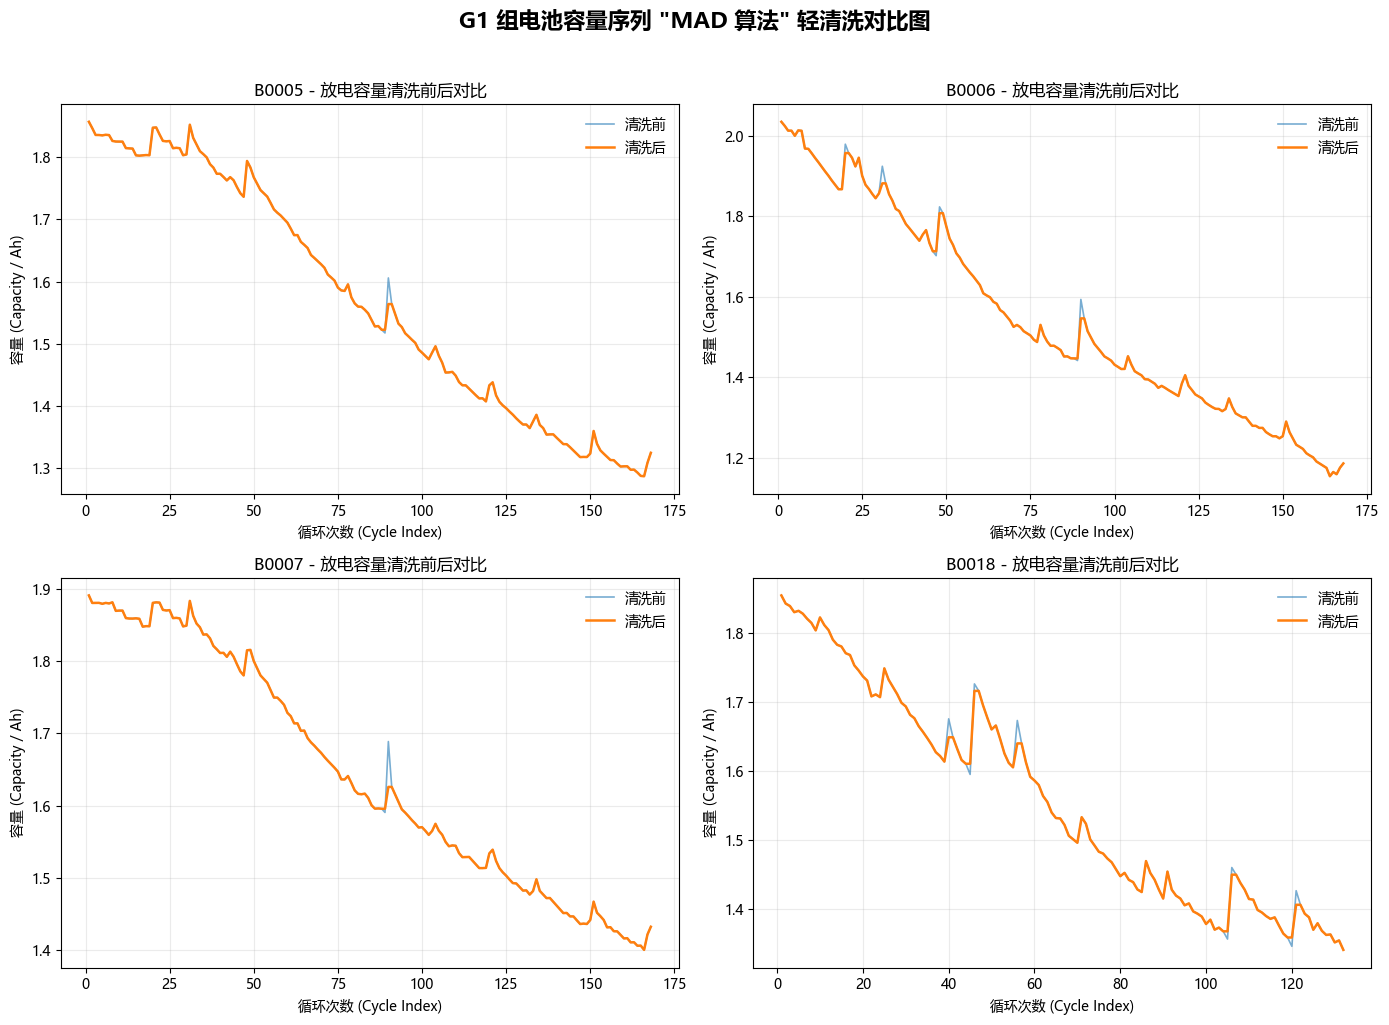

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
from IPython.display import display

# ====================================================
# 1. 字体配置与路径设置
# ====================================================
def setup_chinese_font():
    candidates = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans SC', 'PingFang SC', 'WenQuanYi Zen Hei']
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams['font.sans-serif'] = [name]
            plt.rcParams['axes.unicode_minus'] = False
            return name
    return None
setup_chinese_font()

# 读取前一步保存的放电序列专属文件
PROCESSED_G1_DIR = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge\G1")
G1_BATTERIES = ['B0005', 'B0006', 'B0007', 'B0018']

# ====================================================
# 2. 从笔记本11迁移的 MAD 稳健清洗算法
# ====================================================
def clean_g1_capacity(cap_raw):
    """
    处理 G1 容量数据的非数值与孤立尖峰
    """
    cap_raw = np.asarray(cap_raw).reshape(-1)
    before_points = int(cap_raw.size)

    # 步骤 A：删除非数值(NaN)与非正数点
    cap_num = pd.to_numeric(pd.Series(cap_raw), errors='coerce').to_numpy()
    finite_mask = np.isfinite(cap_num) & (cap_num > 0)
    cap = cap_num[finite_mask].astype(float)
    removed_invalid = int(before_points - cap.size)

    if cap.size < 5:
        return {'before': cap.copy(), 'after': cap.copy(), 'removed_invalid': removed_invalid, 'repaired_spikes': 0}

    # 步骤 B：MAD(绝对中位差)检测与修复“孤立尖峰”，不抹平真实物理老化趋势
    cap_before = cap.copy()
    cap_after = cap.copy()

    # 计算相邻步长的中值差，作为正常退步宽度的基准参数
    d = np.diff(cap_before)
    d_med = np.median(d)
    d_mad = np.median(np.abs(d - d_med))
    robust_sigma = 1.4826 * d_mad if d_mad > 0 else 0.0
    jump_th = max(0.03, 6.0 * robust_sigma)

    repaired_idx = []
    # 忽略头尾节点，寻找“V字形”或“倒V形”的突发毛刺点
    for i in range(1, len(cap_after) - 1):
        left = cap_after[i] - cap_after[i - 1]
        right = cap_after[i + 1] - cap_after[i]
        local_dev = abs(cap_after[i] - 0.5 * (cap_after[i - 1] + cap_after[i + 1]))

        # 判断：必须是方向相反的冲刺（孤立尖峰），并且偏离幅度大于跳变阈值
        is_rebound_shape = (left * right) < 0
        is_large_jump = local_dev > jump_th
        
        if is_rebound_shape and is_large_jump:
            # 使用其前后的值进行插值修复
            cap_after[i] = np.median([cap_after[i - 1], cap_after[i], cap_after[i + 1]])
            repaired_idx.append(i)

    return {
        'before': cap_before,
        'after': cap_after,
        'removed_invalid': removed_invalid,
        'repaired_spikes': len(repaired_idx)
    }

# ====================================================
# 3. 批量清洗执行与数据暂存
# ====================================================
series_map = {}
results = []

for bid in G1_BATTERIES:
    fp = PROCESSED_G1_DIR / f"{bid}_discharge.pkl"
    if not fp.exists():
        print(f"警告: 找不到 {bid} 的数据文件")
        continue
        
    df = pd.read_pickle(fp)
    # 相比笔记11中费力的提取，从我们上一步结构化的 DataFrame 读取 Capacity 非常简单
    cap_raw = df['Capacity'].values
    
    out = clean_g1_capacity(cap_raw)
    series_map[bid] = out
    
    results.append({
        '电池编号': bid,
        '原始循环点数': len(cap_raw),
        '清洗后循环数': len(out['after']),
        '删除非物理点数': out['removed_invalid'],
        '修复尖峰数': out['repaired_spikes']
    })

print("✅ G1组容量数据清洗完毕，统计表如下：")
display(pd.DataFrame(results).style.hide(axis="index"))

# ====================================================
# 4. 可视化清洗前后的对比图
# ====================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, bid in enumerate(G1_BATTERIES):
    ax = axes[i]
    if bid not in series_map:
        ax.text(0.5, 0.5, '无可用数据', ha='center', va='center', transform=ax.transAxes)
        continue
        
    info = series_map[bid]
    cap_before = info['before']
    cap_after = info['after']
    
    x_before = np.arange(1, len(cap_before) + 1)
    x_after = np.arange(1, len(cap_after) + 1)

    ax.plot(x_before, cap_before, label='清洗前', linewidth=1.2, alpha=0.6, color='#1f77b4')
    ax.plot(x_after, cap_after, label='清洗后', linewidth=1.8, color='#ff7f0e')
    ax.set_title(f'{bid} - 放电容量清洗前后对比')
    ax.set_xlabel('循环次数 (Cycle Index)')
    ax.set_ylabel('容量 (Capacity / Ah)')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

plt.suptitle('G1 组电池容量序列 "MAD 算法" 轻清洗对比图', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### G1组其余数据清洗

根据上一节展示的 `B0005` 放电数据特征表，我们可以把其余的时序特征分为 **核心特征（必须清洗）** 和 **冗余特征（无需清洗/直接丢弃）**。

#### 1. 无需清洗 / 建议直接丢弃的特征
*   **`Voltage_load` (负载电压)** 和 **`Current_load` (负载电流)**：这两者记录的是外部电子负载连接时的回路状态。在 NASA 数据集中，电池真实的健康老化情况（极化、内阻增加）主要反映在**直接测量**电池两极的传感器上。负载端的读数受到设备预设和线路损耗的干扰，通常不用于 RUL 特征工程。因此，我们**完全不需要清洗这两列，后续可以直接丢弃**。

#### 2. 建议清洗的核心时序特征
为了后续提取“等效电压降时间”、“温度峰值”等健康因子（Health Indicators, HIs），我们必须清洗以下 **直接测量** 的传感器时序数据：

*   **`Voltage_measured` (测量电压序列_V)**：电池放电时呈现经典的曲线（从 4.2V 下降到 2.7V）。清洗目标是**去除传感器瞬间掉电（如突降到0）或非物理的尖刺**。
*   **`Temperature_measured` (测量温度序列_℃)**：电池放电时温度会逐渐上升。传感器偶尔会因接触不良产生极高或极低的异常离群点。清洗目标是**平滑温度尖峰**。
*   **`Current_measured` (测量电流序列_A)**：G1组是 2A 恒流放电，理想情况下这个序列应当是一条在 -2A 左右波动的平线（NASA中放电电流为负）。清洗目标是**校正瞬时的电流跌落**。
*   **`Time` (时间序列_s)**：这是对齐所有变量的唯一基准。它通常是单调递增的，但不排除存在记录重复或时间倒退的坏点。

#### 3. 稳健的时序清洗策略：Z-Score + 线性插值
针对 `Voltage_measured` 和 `Temperature_measured` 这类高频采样序列，它们在一个循环（Cycle）内是一条连续的物理曲线。我们采用以下策略：
1. 计算相邻点的一阶差分（斜率）。
2. 使用局部窗口（如 rolling window = 5）计算差分的 Z-Score。
3. 当某点的 Z-Score 超过阈值（例如绝对值 > 3）时，判定为传感器“毛刺”。
4. 将该点置为 NaN，然后使用 Pandas 内部的 `interpolate(method='linear')` 进行平滑连线。

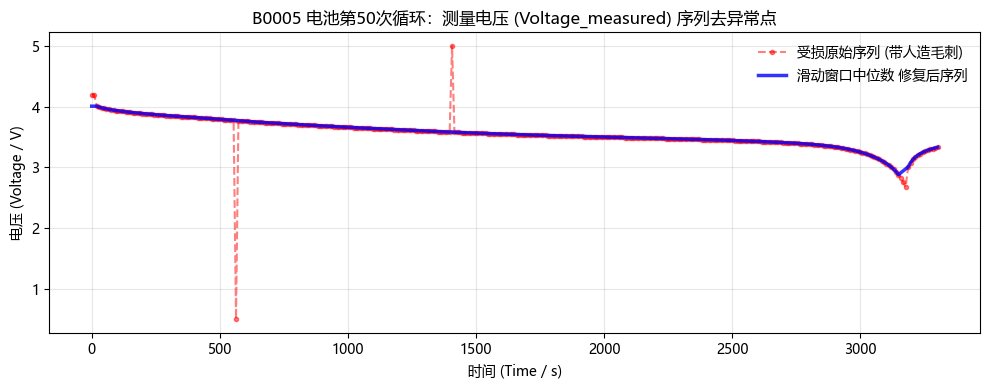

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def clean_time_series_array(arr, window=7):
    """
    针对单条高频时间序列数组进行“去毛刺”与插值。
    修正方案：放弃容易受极端值污染的 Z-Score（均值/方差），改用具备强鲁棒性的 滑动中位数 (Rolling Median) 过滤
    """
    if len(arr) < window:  
        return arr
        
    s = pd.Series(arr)
    
    # 填补潜在的 NaN 和 Inf
    s = s.replace([np.inf, -np.inf], np.nan)
    
    # 步骤1：计算滑动中位数基准线
    # （中位数在遇到明显孤立尖峰时，其本身曲线依然会保持平稳）
    rolling_median = s.rolling(window=window, center=True, min_periods=1).median()
    
    # 步骤2：计算当前点到中位数的绝对偏差
    dev = np.abs(s - rolling_median)
    
    # 步骤3：计算该段信号的“稳健量程”（使用分位数剔除毛刺干扰）
    robust_range = np.nanpercentile(s, 95) - np.nanpercentile(s, 5)
    if robust_range < 1e-3: 
        robust_range = np.nanmedian(np.abs(s))
        
    # 步骤4：设定动态物理阈值。超过该信号物理真实量程的 5% 突变则判定为毛刺，并设定最小基准防止过敏
    threshold = max(robust_range * 0.05, 0.02)
    
    # 步骤5：识别异常点并标记为 NaN
    is_outlier = dev > threshold
    s_cleaned = s.copy()
    s_cleaned[is_outlier] = np.nan
    
    # 步骤6：进行线性插值修复（双向填充）
    s_cleaned = s_cleaned.interpolate(method='linear', limit_direction='both')
    
    return s_cleaned.to_numpy()

# ==========================================
# 仅选取 B0005 电池第 50 次循环的电压序列，作为清洗效果演示
# ==========================================
test_file = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge\G1\B0005_discharge.pkl")
df_test = pd.read_pickle(test_file)

# 提取第 50 次放电的电压原始数据
raw_voltage = df_test.iloc[49]['Voltage_measured']  # Index 49 means Cycle 50
raw_time = df_test.iloc[49]['Time']

# 为了演示，我们“故意”植入两个传感器毛刺（电压瞬间跌落到 0.5V 和冲高到 5.0V）
corrupted_voltage = raw_voltage.copy()
corrupted_voltage[60] = 0.5  # 模拟剧烈跌落
corrupted_voltage[150] = 5.0 # 模拟剧烈冲高

# 使用上述函数进行清洗修复
cleaned_voltage = clean_time_series_array(corrupted_voltage, window=7)

# 绘制验证图
plt.figure(figsize=(10, 4))
plt.plot(raw_time, corrupted_voltage, color='red', alpha=0.5, label='受损原始序列 (带人造毛刺)', linestyle='--', marker='o', markersize=3)
plt.plot(raw_time, cleaned_voltage, color='blue', linewidth=2.5, alpha=0.8, label='滑动窗口中位数 修复后序列')

plt.title('B0005 电池第50次循环：测量电压 (Voltage_measured) 序列去异常点', fontsize=12)
plt.xlabel('时间 (Time / s)')
plt.ylabel('电压 (Voltage / V)')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

以上为展示的情况，效果很好，所以我们对于这个函数进行扩用。扩用到G1其余组的数据中。

开始批量清洗 G1 组多维时序特征（Voltage，Current，Temperature）...
  ✅ [B0005] 时序清洗完成，共处理 168 个循环。
  ✅ [B0006] 时序清洗完成，共处理 168 个循环。
  ✅ [B0007] 时序清洗完成，共处理 168 个循环。
  ✅ [B0018] 时序清洗完成，共处理 132 个循环。

生成清洗前后对比图...


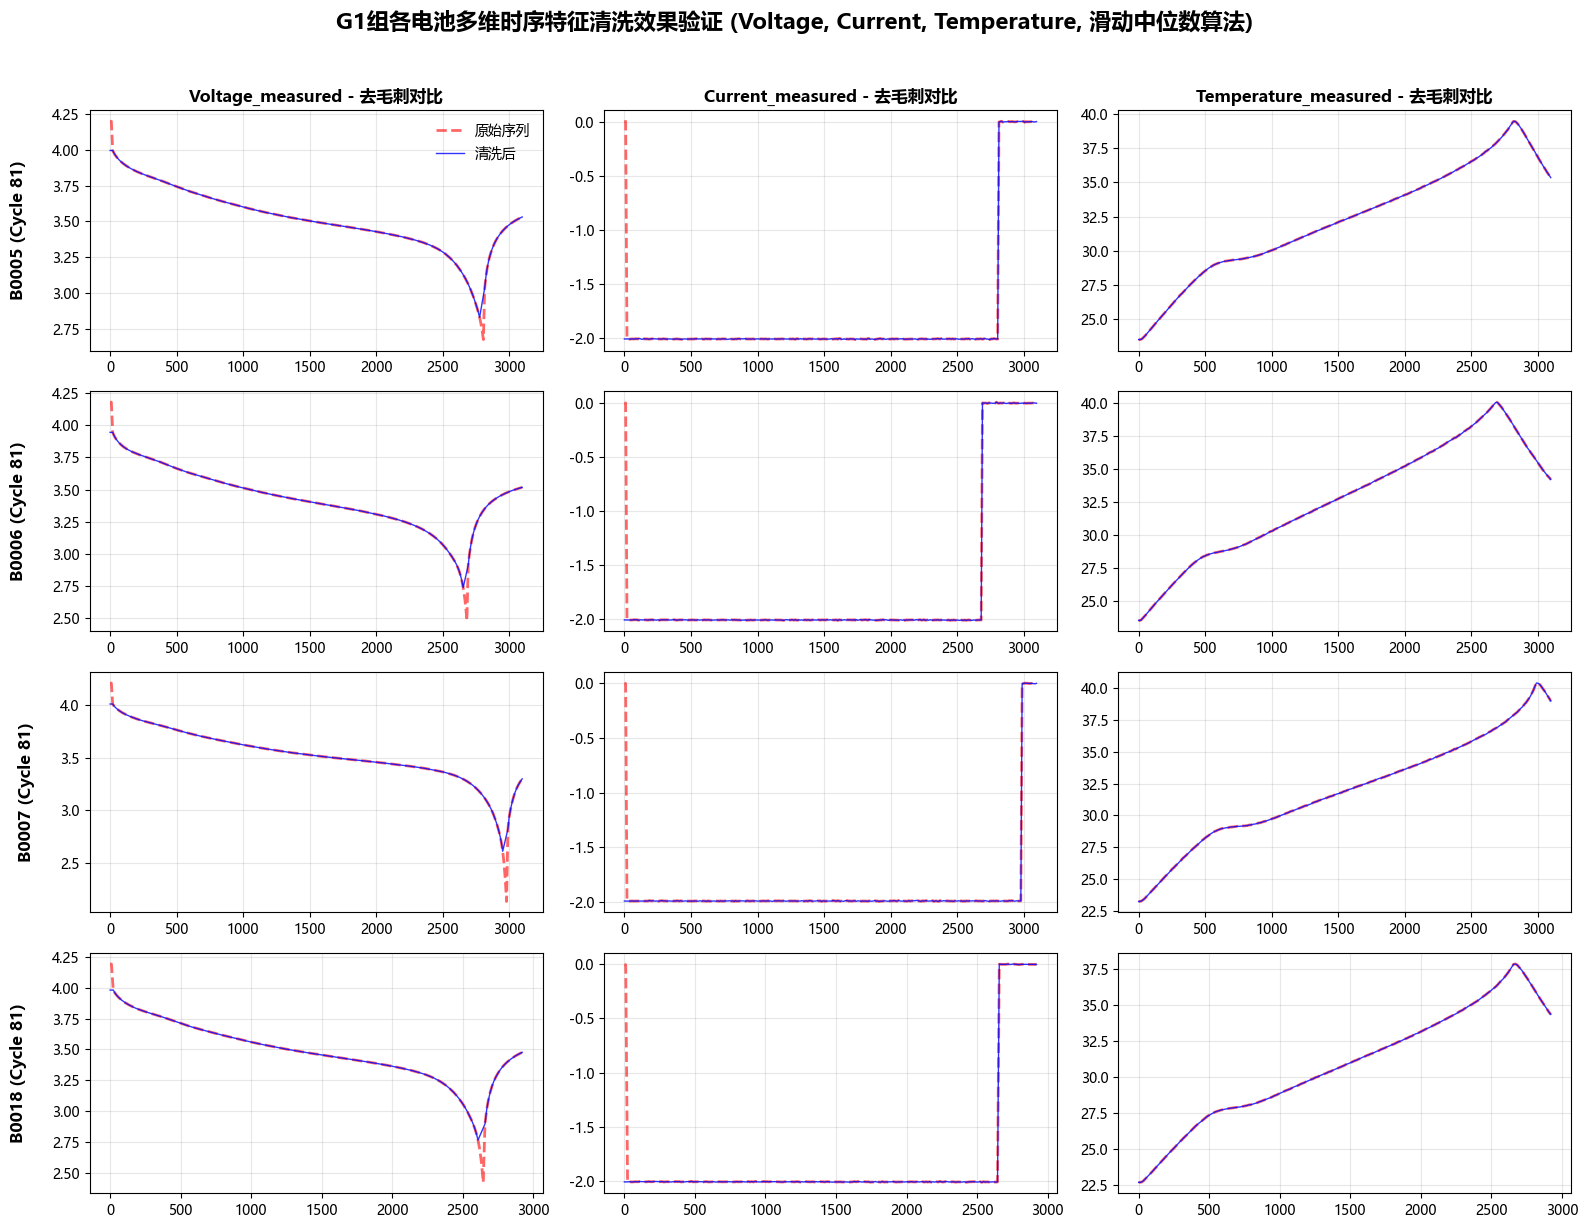

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 读取 G1 组已提取的数据
g1_dir = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge\G1")
g1_bats = ['B0005', 'B0006', 'B0007', 'B0018']

# 需要清洗的高频时序特征
target_features = ['Voltage_measured', 'Current_measured', 'Temperature_measured']
cleaned_g1_data_memory = {}

print("开始批量清洗 G1 组多维时序特征（Voltage，Current，Temperature）...")

for bid in g1_bats:
    file_path = g1_dir / f"{bid}_discharge.pkl"
    if not file_path.exists():
        continue
    
    # 读取原始数据
    df = pd.read_pickle(file_path)
    
    # 针对每一列目标特征，应用去毛刺函数
    for col in target_features:
        # 使用 apply 将清洗函数映射到每一行的 numpy 数组上
        # 我们将清洗后的数据存储在新的列中，以便绘图对比
        df[f'{col}_cleaned'] = df[col].apply(lambda arr: clean_time_series_array(arr, window=7))
        
    cleaned_g1_data_memory[bid] = df
    print(f"  ✅ [{bid}] 时序清洗完成，共处理 {len(df)} 个循环。")


# ==========================================
# 绘图展示清洗效果（纵向：不同电池，横向：三个不同的特征）
# 为了展示，我们随机截取各大电池的 **中后期循环（例如第 80 次循环）**
# ==========================================
print("\n生成清洗前后对比图...")
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 12))
sample_cycle = 80 # 选择第 80 次循环展示

for i, bid in enumerate(g1_bats):
    if bid not in cleaned_g1_data_memory:
        continue
        
    df_plot = cleaned_g1_data_memory[bid]
    # 防止某些电池未达到 80 次循环，取最大可用循环
    c_idx = min(sample_cycle, len(df_plot) - 1)
    
    cycle_data = df_plot.iloc[c_idx]
    time_arr = cycle_data['Time']
    
    for j, col in enumerate(target_features):
        ax = axes[i, j]
        raw_arr = cycle_data[col]
        cleaned_arr = cycle_data[f'{col}_cleaned']
        
        # 原始数据用浅红色虚线
        ax.plot(time_arr, raw_arr, color='red', alpha=0.6, label='原始序列', linestyle='--', linewidth=2)
        # 清洗数据用蓝色实线
        ax.plot(time_arr, cleaned_arr, color='blue', alpha=0.8, label='清洗后', linewidth=1)
        
        # 仅在顶部设置列标题
        if i == 0:
            ax.set_title(f"{col} - 去毛刺对比", fontsize=12, fontweight='bold')
            
        # 仅在左侧设置行标题
        if j == 0:
            ax.set_ylabel(f"{bid} (Cycle {c_idx+1})\n", fontsize=12, fontweight='bold')
            
        ax.grid(alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(loc='best', frameon=False)

plt.suptitle('G1组各电池多维时序特征清洗效果验证 (Voltage, Current, Temperature, 滑动中位数算法)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### G1组数据保存

In [9]:
import os
import pandas as pd
from pathlib import Path

# 定义基础路径和目标路径
save_dir = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\cleaned\G1")
save_dir.mkdir(parents=True, exist_ok=True)

# 确保我们已经有了容量清洗的数据 results(从最上面的单元格) 和 时序清洗的数据 cleaned_g1_data_memory (刚才的单元格)
print(f"准备合并并保存 G1 组清洗后数据至: {save_dir}")

for bid in g1_bats:
    # 1. 提取容量清洗后的数据
    if bid not in series_map:
        print(f"  [跳过] 未找到 {bid} 的容量清洗数据。")
        continue
        
    capacity_cleaned = series_map[bid]['after']
    
    # 2. 提取时序清洗后的数据 DataFrame
    if bid not in cleaned_g1_data_memory:
        print(f"  [跳过] 未找到 {bid} 的时序清洗数据。")
        continue
        
    df_series = cleaned_g1_data_memory[bid].copy()
    
    # 由于原始数据的 Capacity 可能包括了非物理的点(NaN或非正数等)，
    # 我们在容量清洗 (clean_g1_capacity) 时移除了这些点，因此循环次数可能会减少。
    # 这里我们需过滤掉 df_series 里那些在容量清洗时被抛弃的无效循环，以保证循环对齐。
    # 为了简化对齐逻辑，我们假定 clean_g1_capacity 中成功保留的循环具有正向容量，
    # 我们按有效状态在此对原 DataFrame 进行同样的行过滤。
    
    # 获取原始 Capacity，进行掩码过滤
    cap_raw = df_series['Capacity'].values
    cap_num = pd.to_numeric(pd.Series(cap_raw), errors='coerce').to_numpy()
    finite_mask = np.isfinite(cap_num) & (cap_num > 0)
    df_filtered = df_series[finite_mask].copy()
    
    # 再次验证长度是否与清洗后的 Capacity 长度一致
    if len(df_filtered) != len(capacity_cleaned):
        print(f"  [警告] {bid} 的循环次数不对齐! Dataframe 行数={len(df_filtered)}, Capacity 数={len(capacity_cleaned)}")
        # 截断以短的为准
        min_len = min(len(df_filtered), len(capacity_cleaned))
        df_filtered = df_filtered.iloc[:min_len]
        capacity_cleaned = capacity_cleaned[:min_len]
        
    # 3. 合并清洗数据：覆盖原列
    df_filtered['Capacity'] = capacity_cleaned
    
    for col in target_features:
        # 将 '_cleaned' 临时列的值真正覆盖到原本的物理特征列上
        df_filtered[col] = df_filtered[f'{col}_cleaned']
        
    # 4. 剔除不再需要的旧列和中间变量列
    cols_to_drop = ['Voltage_load', 'Current_load'] + [f'{col}_cleaned' for col in target_features]
    df_final = df_filtered.drop(columns=cols_to_drop, errors='ignore')
    
    # 重置索引并重新编号 Cycle_Index (1到N连续)
    df_final = df_final.reset_index(drop=True)
    df_final['Cycle_Index'] = df_final.index + 1
    
    # 5. 保存到磁盘
    save_path = save_dir / f"{bid}_cleaned.pkl"
    df_final.to_pickle(save_path)
    
    # 检查性打印
    print(f"✅ {bid} 处理并保存完毕. 总循环数: {len(df_final)}. ")
    print(f"   保留列: {list(df_final.columns)}")

print("\n🎉 G1 组所有清洗任务顺利完成并保存！")

准备合并并保存 G1 组清洗后数据至: C:\Users\PLUTO\Desktop\battery-rul\data\cleaned\G1
✅ B0005 处理并保存完毕. 总循环数: 168. 
   保留列: ['Battery_ID', 'Cycle_Index', 'Global_Step', 'Voltage_measured', 'Current_measured', 'Temperature_measured', 'Time', 'Capacity']
✅ B0006 处理并保存完毕. 总循环数: 168. 
   保留列: ['Battery_ID', 'Cycle_Index', 'Global_Step', 'Voltage_measured', 'Current_measured', 'Temperature_measured', 'Time', 'Capacity']
✅ B0007 处理并保存完毕. 总循环数: 168. 
   保留列: ['Battery_ID', 'Cycle_Index', 'Global_Step', 'Voltage_measured', 'Current_measured', 'Temperature_measured', 'Time', 'Capacity']
✅ B0018 处理并保存完毕. 总循环数: 132. 
   保留列: ['Battery_ID', 'Cycle_Index', 'Global_Step', 'Voltage_measured', 'Current_measured', 'Temperature_measured', 'Time', 'Capacity']

🎉 G1 组所有清洗任务顺利完成并保存！


## G3组数据清洗

### G3组容量数据清洗

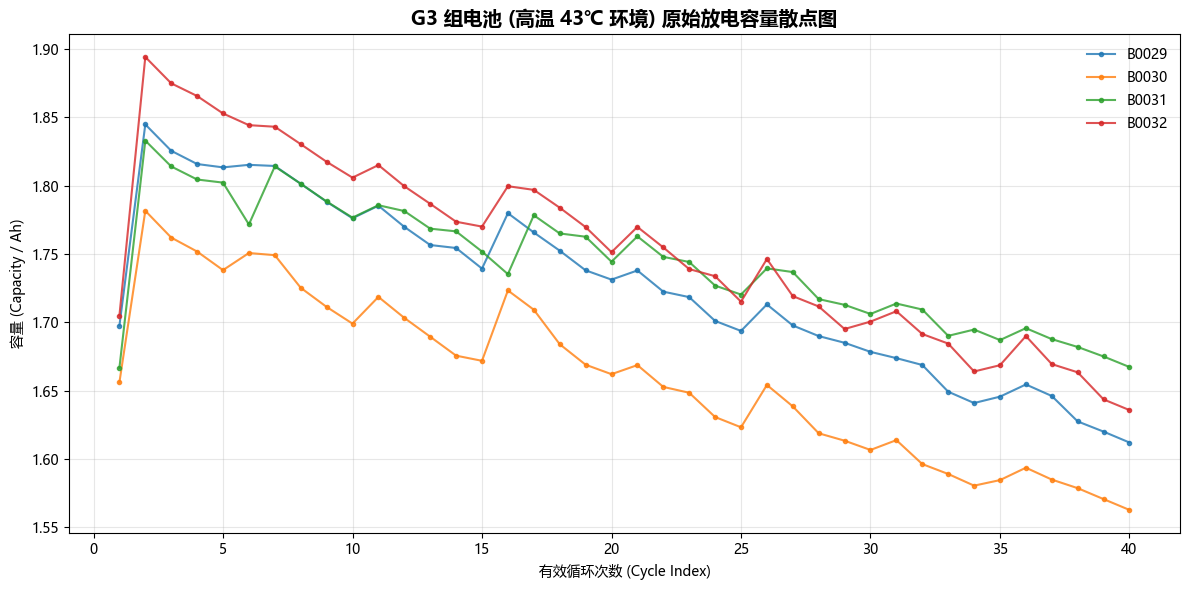

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# G3组电池配置
PROCESSED_G3_DIR = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge\G3")
G3_BATTERIES = ['B0029', 'B0030', 'B0031', 'B0032']

plt.figure(figsize=(12, 6))

for bid in G3_BATTERIES:
    fp = PROCESSED_G3_DIR / f"{bid}_discharge.pkl"
    if not fp.exists():
        print(f"警告: 找不到 {bid} 的数据文件")
        continue
        
    df = pd.read_pickle(fp)
    
    # 提取容量数据
    cap_raw = df['Capacity'].values
    
    # 排除完全不合理的 NaN 或非正数
    cap_num = pd.to_numeric(pd.Series(cap_raw), errors='coerce').to_numpy()
    finite_mask = np.isfinite(cap_num) & (cap_num > 0)
    cap_valid = cap_num[finite_mask]
    
    # 绘制原始分布图
    plt.plot(np.arange(1, len(cap_valid) + 1), cap_valid, 
             label=f"{bid}", marker='o', markersize=3, linewidth=1.5, alpha=0.8)

plt.title('G3 组电池 (高温 43℃ 环境) 原始放电容量散点图', fontsize=14, fontweight='bold')
plt.xlabel('有效循环次数 (Cycle Index)')
plt.ylabel('容量 (Capacity / Ah)')
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

✅ 正在执行 G3 组容量清洗...


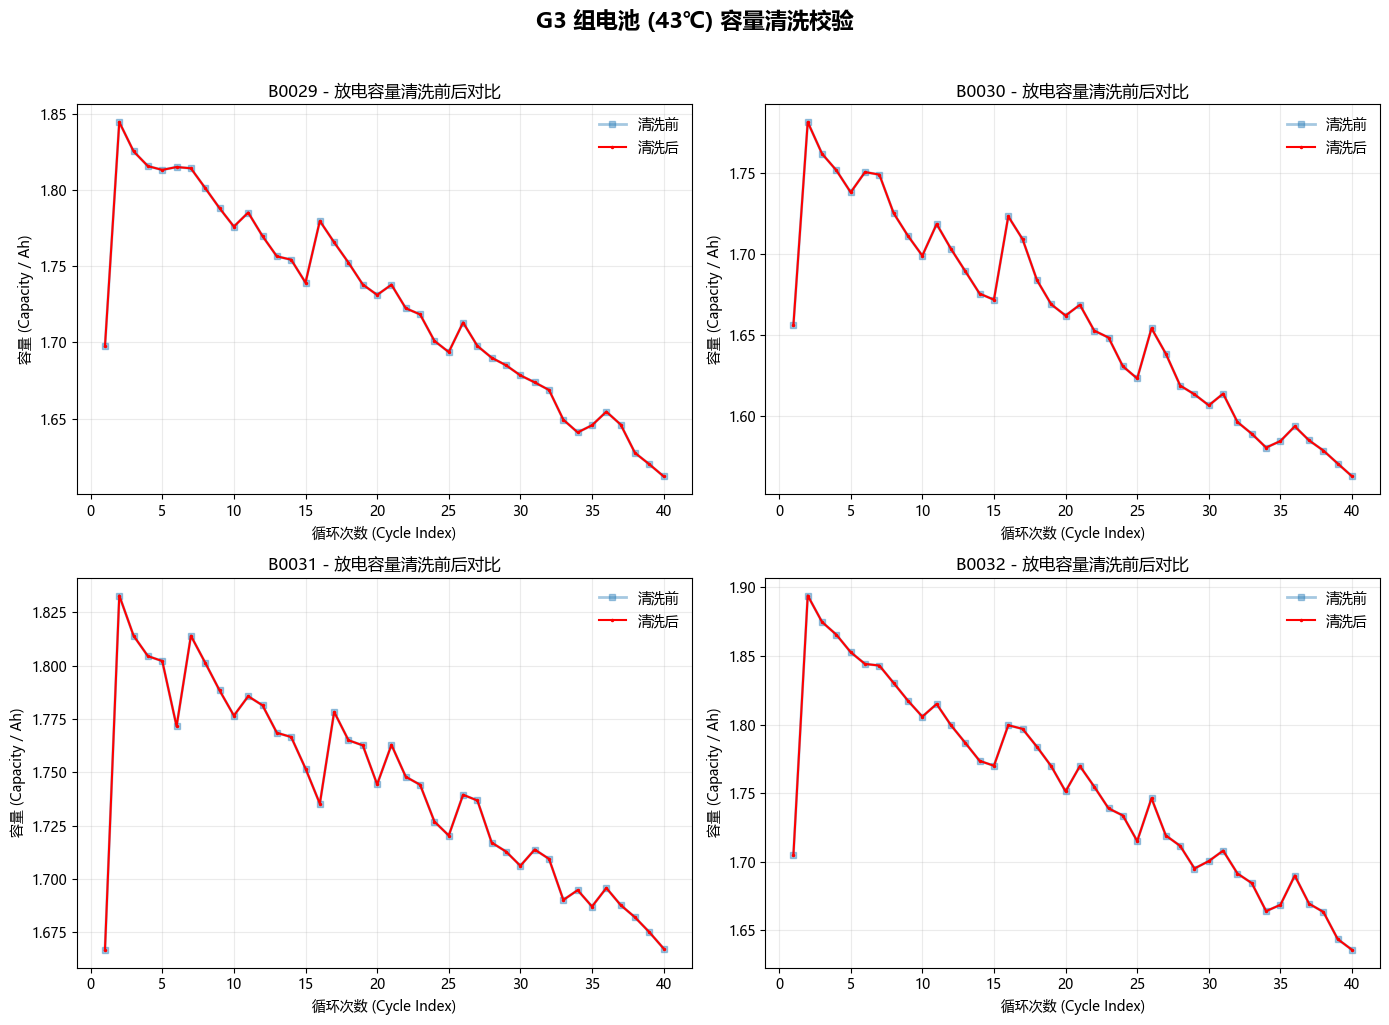

In [11]:
# ====================================================
# G3 组容量清洗：稳健 MAD 算法 (适应高温高波动宽容度)
# ====================================================

def clean_g3_capacity(cap_raw):
    cap_raw = np.asarray(cap_raw).reshape(-1)
    before_points = int(cap_raw.size)

    # A. 过滤有效数值
    cap_num = pd.to_numeric(pd.Series(cap_raw), errors='coerce').to_numpy()
    finite_mask = np.isfinite(cap_num) & (cap_num > 0)
    cap = cap_num[finite_mask].astype(float)
    removed_invalid = int(before_points - cap.size)

    if cap.size < 5:
        return {'before': cap.copy(), 'after': cap.copy(), 'removed_invalid': removed_invalid, 'repaired_spikes': 0}

    cap_before = cap.copy()
    cap_after = cap.copy()

    # B. MAD 检测 (针对高温稍微放宽阈值，避免误杀高温引发的真实'容量回升(Regeneration)')
    d = np.diff(cap_before)
    d_med = np.median(d)
    d_mad = np.median(np.abs(d - d_med))
    robust_sigma = 1.4826 * d_mad if d_mad > 0 else 0.0
    
    # 相比 G1(0.03)，对于 43℃，我们把绝对跳变阈值设为 0.05
    jump_th = max(0.05, 5.0 * robust_sigma) 

    repaired_idx = []
    
    # 我们故意忽略前几个点，强行保留其"激活爬升期"不受任何干扰
    start_idx = 3 
    
    for i in range(start_idx, len(cap_after) - 1):
        left = cap_after[i] - cap_after[i - 1]
        right = cap_after[i + 1] - cap_after[i]
        local_dev = abs(cap_after[i] - 0.5 * (cap_after[i - 1] + cap_after[i + 1]))

        # 只剔除极其突兀的孤立毛刺
        is_rebound_shape = (left * right) < 0
        is_large_jump = local_dev > jump_th
        
        if is_rebound_shape and is_large_jump:
            cap_after[i] = np.median([cap_after[i - 1], cap_after[i], cap_after[i + 1]])
            repaired_idx.append(i)

    return {
        'before': cap_before,
        'after': cap_after,
        'removed_invalid': removed_invalid,
        'repaired_spikes': len(repaired_idx)
    }

# ====================================================
# 执行清洗及可视化
# ====================================================
g3_series_map = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

print("✅ 正在执行 G3 组容量清洗...")

for i, bid in enumerate(G3_BATTERIES):
    fp = PROCESSED_G3_DIR / f"{bid}_discharge.pkl"
    if not fp.exists():
        continue
        
    df = pd.read_pickle(fp)
    cap_raw = df['Capacity'].values
    
    out = clean_g3_capacity(cap_raw)
    g3_series_map[bid] = out
    
    # 绘图展示对比
    ax = axes[i]
    x_before = np.arange(1, len(out['before']) + 1)
    x_after = np.arange(1, len(out['after']) + 1)

    ax.plot(x_before, out['before'], label='清洗前', linewidth=2, alpha=0.4, color='#1f77b4', marker='s', markersize=4)
    ax.plot(x_after, out['after'], label='清洗后', linewidth=1.5, color='red', marker='.', markersize=3)
    
    ax.set_title(f'{bid} - 放电容量清洗前后对比')
    ax.set_xlabel('循环次数 (Cycle Index)')
    ax.set_ylabel('容量 (Capacity / Ah)')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

plt.suptitle('G3 组电池 (43℃) 容量清洗校验', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### G3组其余数据列清洗

在完成数据容量清洗之后，我们开始对G3组进行其余列的清洗

开始批量清洗 G3 组多维时序特征（Voltage，Current，Temperature）...
  ✅ [B0029] G3时序清洗完成，共处理 40 个循环。
  ✅ [B0030] G3时序清洗完成，共处理 40 个循环。
  ✅ [B0031] G3时序清洗完成，共处理 40 个循环。
  ✅ [B0032] G3时序清洗完成，共处理 40 个循环。

生成清洗前后对比图 (G3 测试)...


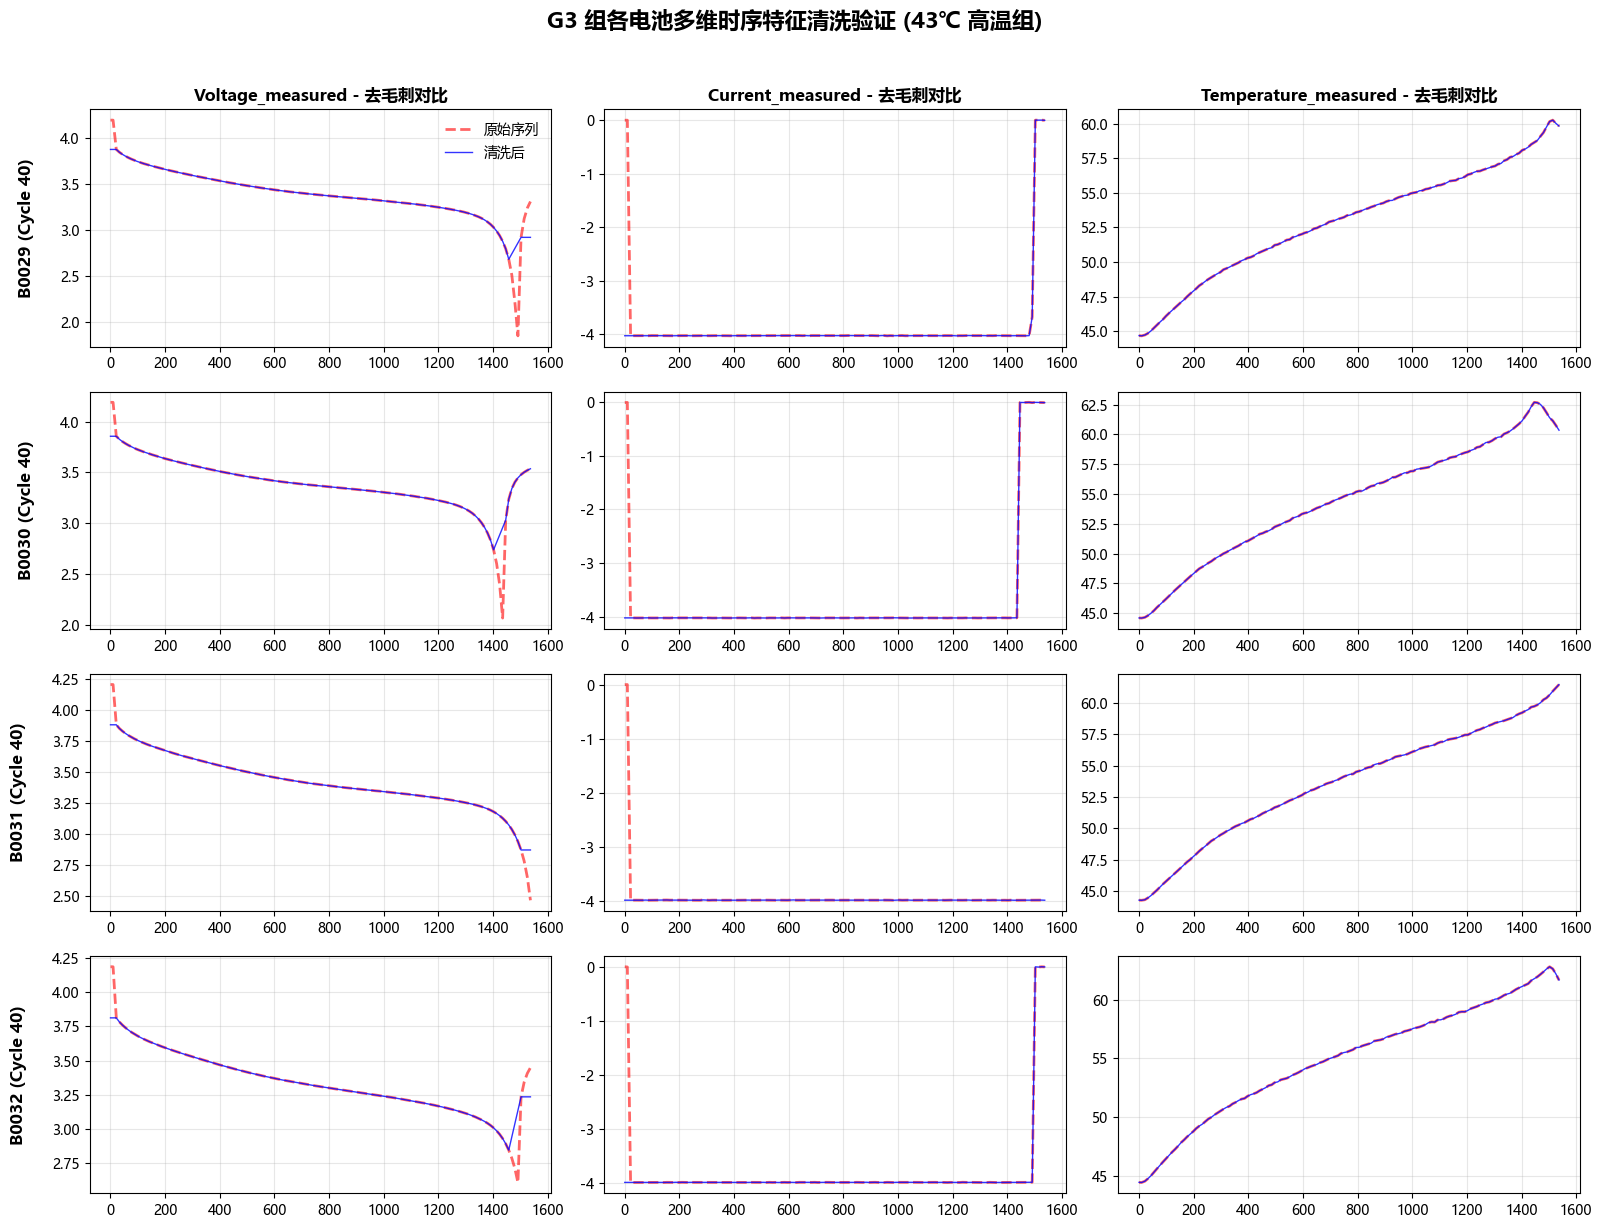

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ====================================================
# G3 组多维时序特征清洗 (沿用 G1 的滑动中位数去毛刺算法)
# ====================================================

g3_dir = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge\G3")
# G3 组电池：B0029, B0030, B0031, B0032
g3_bats = ['B0029', 'B0030', 'B0031', 'B0032']

cleaned_g3_data_memory = {}

print("开始批量清洗 G3 组多维时序特征（Voltage，Current，Temperature）...")

for bid in g3_bats:
    file_path = g3_dir / f"{bid}_discharge.pkl"
    if not file_path.exists():
        continue
    
    df = pd.read_pickle(file_path)
    
    # 针对每一列目标特征，应用与G1相同的去毛刺函数 clean_time_series_array
    for col in target_features:
        df[f'{col}_cleaned'] = df[col].apply(lambda arr: clean_time_series_array(arr, window=7))
        
    cleaned_g3_data_memory[bid] = df
    print(f"  ✅ [{bid}] G3时序清洗完成，共处理 {len(df)} 个循环。")

# ==========================================
# 绘图展示 G3 时序清洗效果
# 选择靠后的循环观测高温后期的信号毛刺情况
# ==========================================
print("\n生成清洗前后对比图 (G3 测试)...")
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 12))
sample_cycle_g3 = 100 # G3组循环较多，我们截取第100次循环进行展示

for i, bid in enumerate(g3_bats):
    if bid not in cleaned_g3_data_memory:
        continue
        
    df_plot = cleaned_g3_data_memory[bid]
    c_idx = min(sample_cycle_g3, len(df_plot) - 1)
    
    cycle_data = df_plot.iloc[c_idx]
    time_arr = cycle_data['Time']
    
    for j, col in enumerate(target_features):
        ax = axes[i, j]
        raw_arr = cycle_data[col]
        cleaned_arr = cycle_data[f'{col}_cleaned']
        
        # 原始数据用浅红色虚线表示
        ax.plot(time_arr, raw_arr, color='red', alpha=0.6, label='原始序列', linestyle='--', linewidth=2)
        # 清洗数据用蓝色实线表示
        ax.plot(time_arr, cleaned_arr, color='blue', alpha=0.8, label='清洗后', linewidth=1)
        
        if i == 0:
            ax.set_title(f"{col} - 去毛刺对比", fontsize=12, fontweight='bold')
            
        if j == 0:
            ax.set_ylabel(f"{bid} (Cycle {c_idx+1})\n", fontsize=12, fontweight='bold')
            
        ax.grid(alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(loc='best', frameon=False)

plt.suptitle('G3 组各电池多维时序特征清洗验证 (43℃ 高温组)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### G3组数据保存

这部分用于保存G3组的数据到"C:\Users\PLUTO\Desktop\battery-rul\data\cleaned\G3"

In [13]:
import os
import pandas as pd
from pathlib import Path

# 定义基础保存路径
save_dir_g3 = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\cleaned\G3")
save_dir_g3.mkdir(parents=True, exist_ok=True)

print(f"准备合并并保存 G3 组清洗后数据至: {save_dir_g3}")

for bid in g3_bats:
    # 1. 提取 G3 组容量清洗结果
    if bid not in g3_series_map:
        print(f"  [跳过] 未找到 {bid} 的容量清洗数据。")
        continue
    capacity_cleaned = g3_series_map[bid]['after']
    
    # 2. 提取 G3 组时序清洗结果
    if bid not in cleaned_g3_data_memory:
        print(f"  [跳过] 未找到 {bid} 的时序清洗数据。")
        continue
    df_series = cleaned_g3_data_memory[bid].copy()
    
    # 3. 过滤出有效循环 (和 clean_g3_capacity 内部规则一致: isfinite 且 > 0)
    cap_raw = df_series['Capacity'].values
    cap_num = pd.to_numeric(pd.Series(cap_raw), errors='coerce').to_numpy()
    finite_mask = np.isfinite(cap_num) & (cap_num > 0)
    df_filtered = df_series[finite_mask].copy()
    
    # === 增强的安全校验 ===
    if len(df_filtered) != len(capacity_cleaned):
        print(f"  [警告] {bid} 的循环行数不对齐! 特征表行数: {len(df_filtered)}, 容量数组长度: {len(capacity_cleaned)}")
        # 进行自动截断对齐
        min_len = min(len(df_filtered), len(capacity_cleaned))
        df_filtered = df_filtered.iloc[:min_len]
        capacity_cleaned = capacity_cleaned[:min_len]
    
    # 4. 把干干净净的特征覆盖写入最终 DataFrame
    df_filtered['Capacity'] = capacity_cleaned
    for col in target_features:
        df_filtered[col] = df_filtered[f'{col}_cleaned']
        
    # 5. 剔除噪声、无用变量以及内存中间项
    cols_to_drop = ['Voltage_load', 'Current_load'] + [f'{col}_cleaned' for col in target_features]
    df_final = df_filtered.drop(columns=cols_to_drop, errors='ignore')
    
    # 重置索引并提供纯净连续的 Cycle_Index
    df_final = df_final.reset_index(drop=True)
    df_final['Cycle_Index'] = df_final.index + 1
    
    # 6. 数据双重校验：检查是否还含有恶意的 NaN 值
    nan_check = df_final[['Capacity', 'Voltage_measured']].isnull().sum().sum()
    if nan_check > 0:
        print(f"  [异常报警] 电池 {bid} 依然存在未清除的 NaN 值！")
    
    # 7. 落盘保存为 Pickle
    save_path = save_dir_g3 / f"{bid}_cleaned.pkl"
    df_final.to_pickle(save_path)
    
    print(f"✅ [{bid}] 数据合并无误并保存. 总共可用循环数: {len(df_final)}")
    
print("\n🎉 G3 组数据清洗及整合落盘任务全部完成！")

准备合并并保存 G3 组清洗后数据至: C:\Users\PLUTO\Desktop\battery-rul\data\cleaned\G3
✅ [B0029] 数据合并无误并保存. 总共可用循环数: 40
✅ [B0030] 数据合并无误并保存. 总共可用循环数: 40
✅ [B0031] 数据合并无误并保存. 总共可用循环数: 40
✅ [B0032] 数据合并无误并保存. 总共可用循环数: 40

🎉 G3 组数据清洗及整合落盘任务全部完成！


# G9组数据清洗

## G9组容量清洗

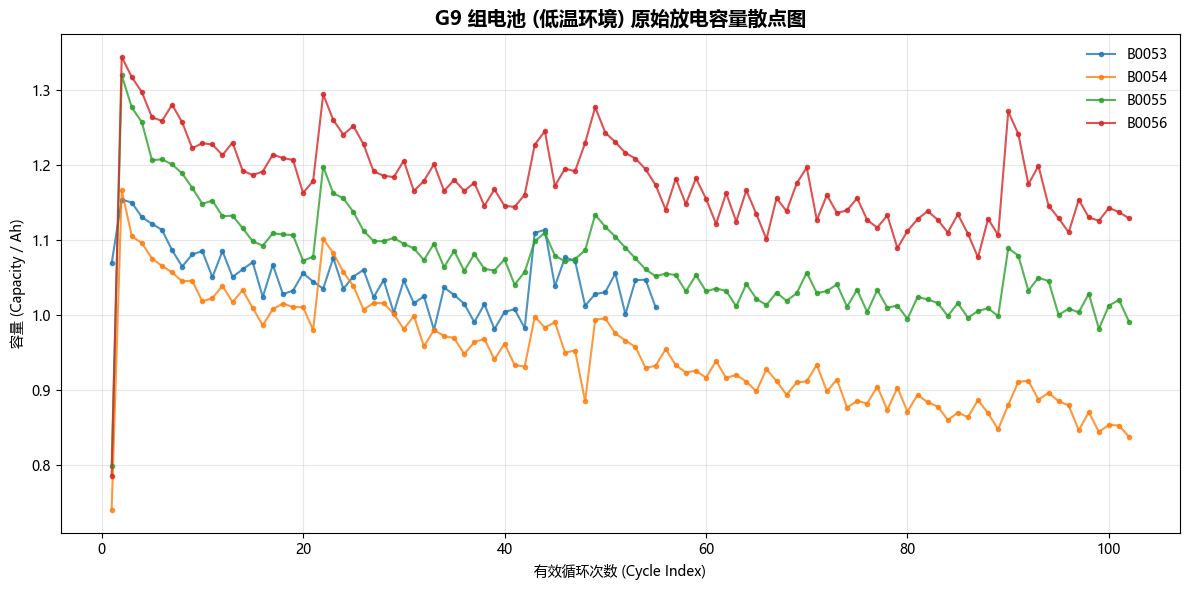

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# G9组电池配置
PROCESSED_G9_DIR = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge\G9")
# G9组 (通常为4℃低温老化实验)：B0053, B0054, B0055, B0056
G9_BATTERIES = ['B0053', 'B0054', 'B0055', 'B0056']

plt.figure(figsize=(12, 6))

for bid in G9_BATTERIES:
    fp = PROCESSED_G9_DIR / f"{bid}_discharge.pkl"
    if not fp.exists():
        print(f"警告: 找不到 {bid} 的数据文件")
        continue
        
    df = pd.read_pickle(fp)
    
    # 提取容量数据
    cap_raw = df['Capacity'].values
    
    # 排除完全不合理的 NaN 或非正数
    cap_num = pd.to_numeric(pd.Series(cap_raw), errors='coerce').to_numpy()
    finite_mask = np.isfinite(cap_num) & (cap_num > 0)
    cap_valid = cap_num[finite_mask]
    
    # 绘制原始分布图
    plt.plot(np.arange(1, len(cap_valid) + 1), cap_valid, 
             label=f"{bid}", marker='o', markersize=3, linewidth=1.5, alpha=0.8)

plt.title('G9 组电池 (低温环境) 原始放电容量散点图', fontsize=14, fontweight='bold')
plt.xlabel('有效循环次数 (Cycle Index)')
plt.ylabel('容量 (Capacity / Ah)')
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

✅ 正在执行 G9 组容量清洗...


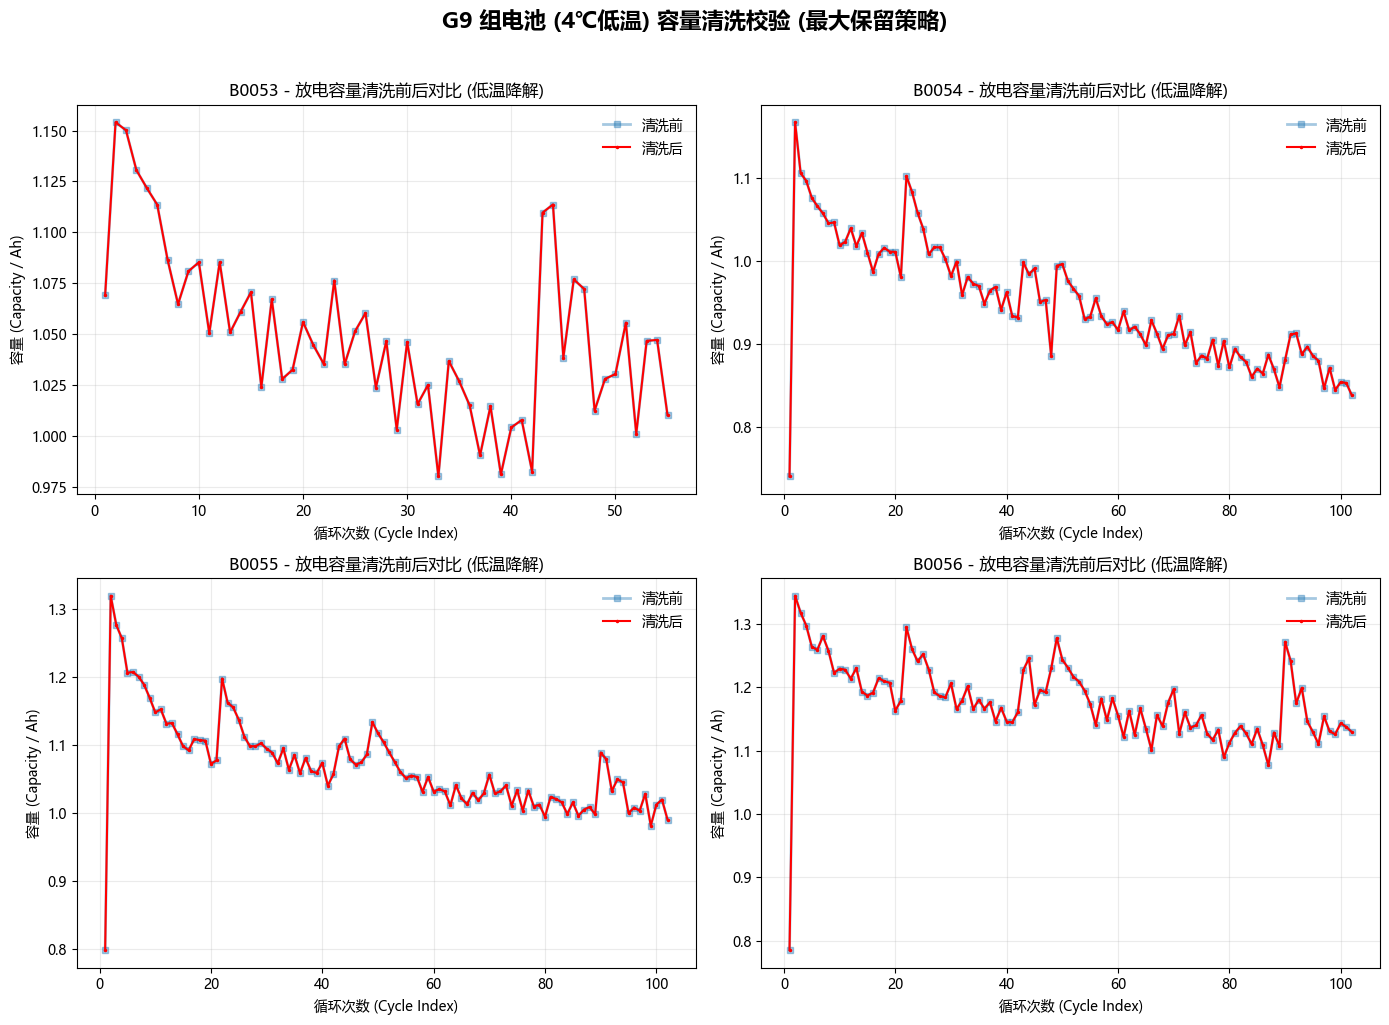

In [15]:
# ====================================================
# G9 组容量清洗：稳健 MAD 算法 (适应低温极高波动的宽容度)
# ====================================================

def clean_g9_capacity(cap_raw):
    cap_raw = np.asarray(cap_raw).reshape(-1)
    before_points = int(cap_raw.size)

    # A. 过滤有效数值
    cap_num = pd.to_numeric(pd.Series(cap_raw), errors='coerce').to_numpy()
    finite_mask = np.isfinite(cap_num) & (cap_num > 0)
    cap = cap_num[finite_mask].astype(float)
    removed_invalid = int(before_points - cap.size)

    if cap.size < 5:
        return {'before': cap.copy(), 'after': cap.copy(), 'removed_invalid': removed_invalid, 'repaired_spikes': 0}

    cap_before = cap.copy()
    cap_after = cap.copy()

    # B. MAD 检测 (针对低温波动极大的特性，采用最大宽容度)
    d = np.diff(cap_before)
    d_med = np.median(d)
    d_mad = np.median(np.abs(d - d_med))
    robust_sigma = 1.4826 * d_mad if d_mad > 0 else 0.0
    
    # 阈值放宽到 0.08，使得极端的“容量再生(Regeneration)”被视为正常物理现象保留下来
    jump_th = max(0.08, 5.0 * robust_sigma) 

    repaired_idx = []
    
    # 低温条件存在明显的“冷启动容量深谷”，我们强行跳过前两个点，不作任何干预
    start_idx = 2 
    
    for i in range(start_idx, len(cap_after) - 1):
        left = cap_after[i] - cap_after[i - 1]
        right = cap_after[i + 1] - cap_after[i]
        local_dev = abs(cap_after[i] - 0.5 * (cap_after[i - 1] + cap_after[i + 1]))

        # 只剔除极端突兀的孤立毛刺 (多数锯齿状将被保留)
        is_rebound_shape = (left * right) < 0
        is_large_jump = local_dev > jump_th
        
        if is_rebound_shape and is_large_jump:
            cap_after[i] = np.median([cap_after[i - 1], cap_after[i], cap_after[i + 1]])
            repaired_idx.append(i)

    return {
        'before': cap_before,
        'after': cap_after,
        'removed_invalid': removed_invalid,
        'repaired_spikes': len(repaired_idx)
    }

# ====================================================
# 执行清洗及可视化
# ====================================================
g9_series_map = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

print("✅ 正在执行 G9 组容量清洗...")

for i, bid in enumerate(G9_BATTERIES):
    fp = PROCESSED_G9_DIR / f"{bid}_discharge.pkl"
    if not fp.exists():
        continue
        
    df = pd.read_pickle(fp)
    cap_raw = df['Capacity'].values
    
    out = clean_g9_capacity(cap_raw)
    g9_series_map[bid] = out
    
    # 绘图展示对比
    ax = axes[i]
    x_before = np.arange(1, len(out['before']) + 1)
    x_after = np.arange(1, len(out['after']) + 1)

    ax.plot(x_before, out['before'], label='清洗前', linewidth=2, alpha=0.4, color='#1f77b4', marker='s', markersize=4)
    ax.plot(x_after, out['after'], label='清洗后', linewidth=1.5, color='red', marker='.', markersize=3)
    
    ax.set_title(f'{bid} - 放电容量清洗前后对比 (低温降解)')
    ax.set_xlabel('循环次数 (Cycle Index)')
    ax.set_ylabel('容量 (Capacity / Ah)')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

plt.suptitle('G9 组电池 (4℃低温) 容量清洗校验 (最大保留策略)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### G9组剩余数据列清洗

开始批量清洗 G9 组多维时序特征（Voltage，Current，Temperature）...
  ✅ [B0053] 时序清洗完成，共处理 56 个循环。
  ✅ [B0054] 时序清洗完成，共处理 103 个循环。
  ✅ [B0055] 时序清洗完成，共处理 102 个循环。
  ✅ [B0056] 时序清洗完成，共处理 102 个循环。

生成清洗前后对比图 (G9 低温测试)...


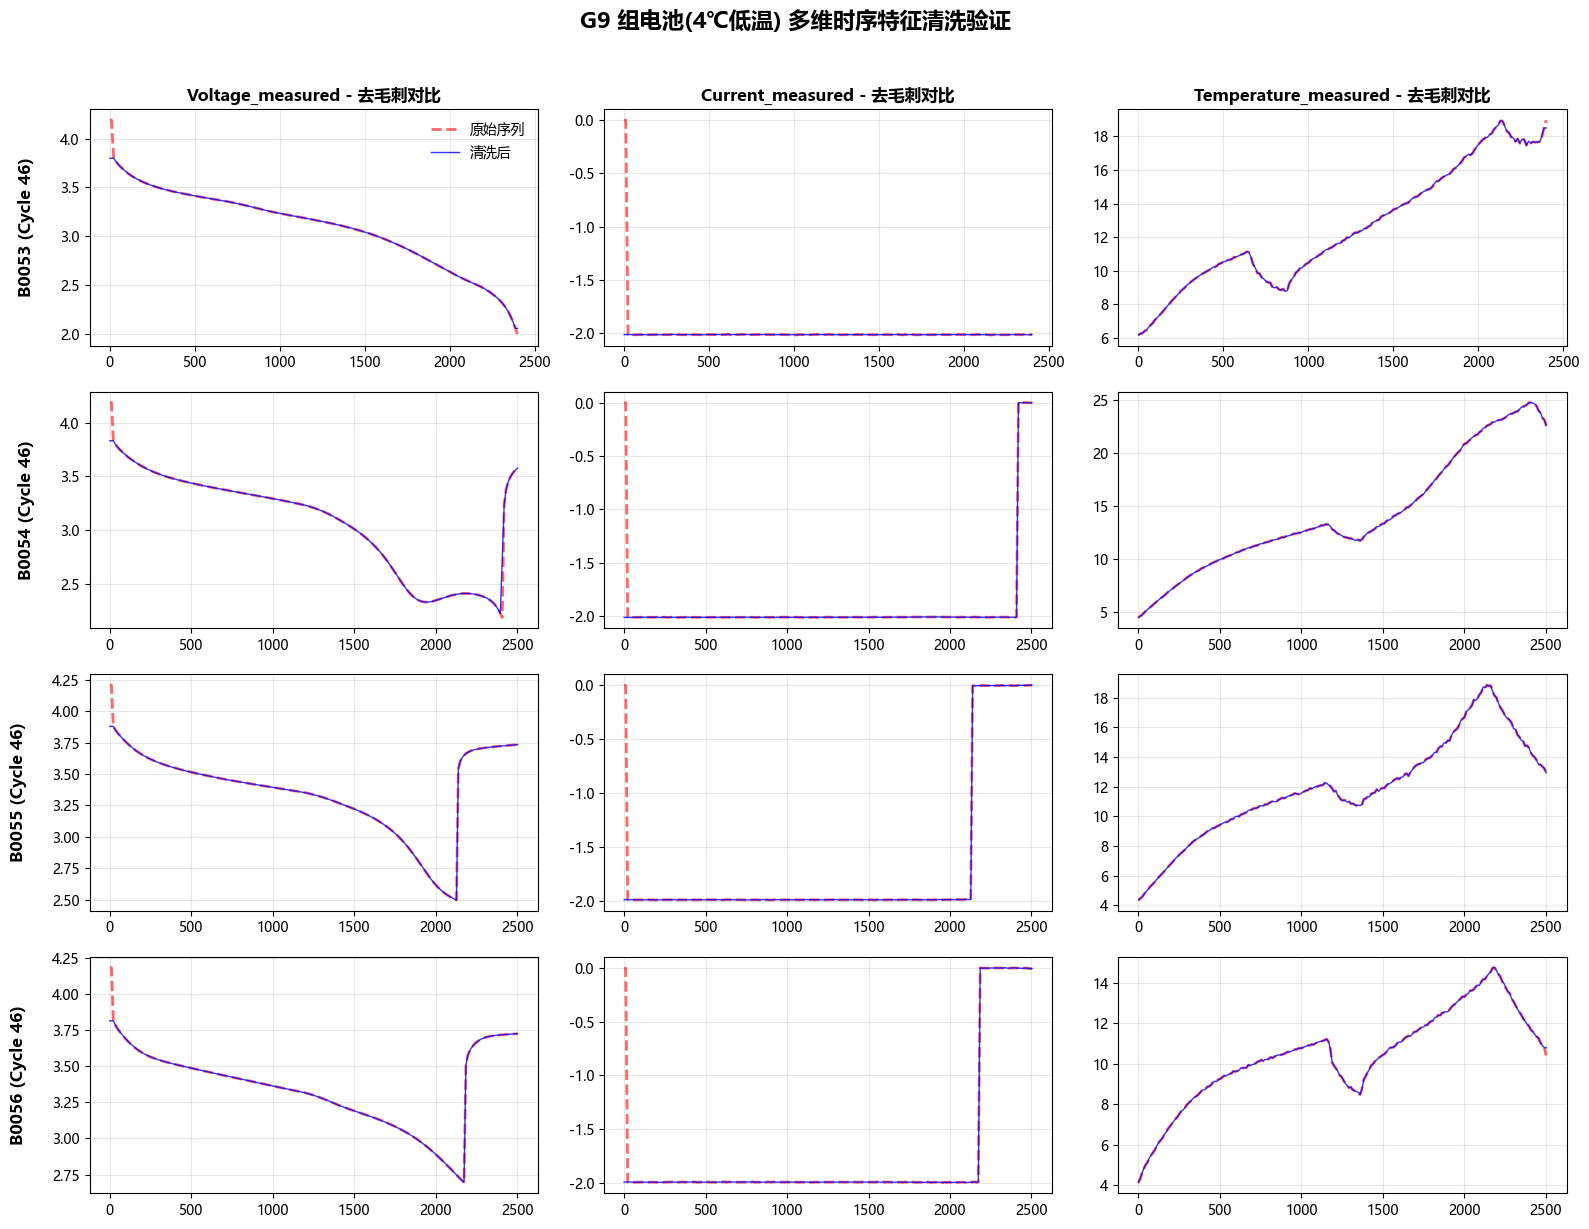

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ====================================================
# G9 组多维时序特征清洗 (沿用滑动中位数彻底去除高频毛刺)
# ====================================================

g9_dir = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\processed\discharge\G9")
# G9 组电池 (低温环境)
g9_bats = ['B0053', 'B0054', 'B0055', 'B0056']

# 待清洗的核心传感器特征
target_features = ['Voltage_measured', 'Current_measured', 'Temperature_measured']

cleaned_g9_data_memory = {}

print("开始批量清洗 G9 组多维时序特征（Voltage，Current，Temperature）...")

for bid in g9_bats:
    file_path = g9_dir / f"{bid}_discharge.pkl"
    if not file_path.exists():
        continue
    
    df = pd.read_pickle(file_path)
    
    # 针对每一列目标特征，应用去毛刺函数 clean_time_series_array
    for col in target_features:
        df[f'{col}_cleaned'] = df[col].apply(lambda arr: clean_time_series_array(arr, window=7))
        
    cleaned_g9_data_memory[bid] = df
    print(f"  ✅ [{bid}] 时序清洗完成，共处理 {len(df)} 个循环。")

# ==========================================
# 绘图展示 G9 时序清洗效果
# 注意：低温环境下的温度传感器可能会出现极度陡峭或被放大的毛刺
# ==========================================
print("\n生成清洗前后对比图 (G9 低温测试)...")
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 12))
# 我们截取第 45 次循环进行展示，此时经过了初期的重度波动
sample_cycle_g9 = 45 

for i, bid in enumerate(g9_bats):
    if bid not in cleaned_g9_data_memory:
        continue
        
    df_plot = cleaned_g9_data_memory[bid]
    c_idx = min(sample_cycle_g9, len(df_plot) - 1)
    
    cycle_data = df_plot.iloc[c_idx]
    time_arr = cycle_data['Time']
    
    for j, col in enumerate(target_features):
        ax = axes[i, j]
        raw_arr = cycle_data[col]
        cleaned_arr = cycle_data[f'{col}_cleaned']
        
        # 原始数据用浅红色虚线表示
        ax.plot(time_arr, raw_arr, color='red', alpha=0.6, label='原始序列', linestyle='--', linewidth=2)
        # 清洗数据用蓝色实线表示
        ax.plot(time_arr, cleaned_arr, color='blue', alpha=0.8, label='清洗后', linewidth=1)
        
        if i == 0:
            ax.set_title(f"{col} - 去毛刺对比", fontsize=12, fontweight='bold')
            
        if j == 0:
            ax.set_ylabel(f"{bid} (Cycle {c_idx+1})\n", fontsize=12, fontweight='bold')
            
        ax.grid(alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(loc='best', frameon=False)

plt.suptitle('G9 组电池(4℃低温) 多维时序特征清洗验证', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### G9组数据保存

In [17]:
import os
import pandas as pd
from pathlib import Path

# 定义基础保存路径
save_dir_g9 = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\cleaned\G9")
save_dir_g9.mkdir(parents=True, exist_ok=True)

print(f"准备合并并保存 G9 组清洗后数据至: {save_dir_g9}")

for bid in g9_bats:
    # 1. 提取 G9 组容量清洗结果
    if bid not in g9_series_map:
        print(f"  [跳过] 未找到 {bid} 的容量清洗数据。")
        continue
    capacity_cleaned = g9_series_map[bid]['after']
    
    # 2. 提取 G9 组时序清洗结果
    if bid not in cleaned_g9_data_memory:
        print(f"  [跳过] 未找到 {bid} 的时序清洗数据。")
        continue
    df_series = cleaned_g9_data_memory[bid].copy()
    
    # 3. 过滤出有效循环 (和 clean_g9_capacity 内部规则一致: isfinite 且 > 0)
    cap_raw = df_series['Capacity'].values
    cap_num = pd.to_numeric(pd.Series(cap_raw), errors='coerce').to_numpy()
    finite_mask = np.isfinite(cap_num) & (cap_num > 0)
    df_filtered = df_series[finite_mask].copy()
    
    # === 增强的安全校验 ===
    if len(df_filtered) != len(capacity_cleaned):
        print(f"  [警告] {bid} 的循环行数不对齐! 特征表行数: {len(df_filtered)}, 容量数组长度: {len(capacity_cleaned)}")
        # 进行自动截断对齐
        min_len = min(len(df_filtered), len(capacity_cleaned))
        df_filtered = df_filtered.iloc[:min_len]
        capacity_cleaned = capacity_cleaned[:min_len]
    
    # 4. 把干干净净的特征覆盖写入最终 DataFrame
    df_filtered['Capacity'] = capacity_cleaned
    for col in target_features:
        df_filtered[col] = df_filtered[f'{col}_cleaned']
        
    # 5. 剔除噪声、无用变量以及内存中间项
    cols_to_drop = ['Voltage_load', 'Current_load'] + [f'{col}_cleaned' for col in target_features]
    df_final = df_filtered.drop(columns=cols_to_drop, errors='ignore')
    
    # 重置索引并提供纯净连续的 Cycle_Index
    df_final = df_final.reset_index(drop=True)
    df_final['Cycle_Index'] = df_final.index + 1
    
    # 6. 数据双重校验：检查是否还含有恶意的 NaN 值
    nan_check = df_final[['Capacity', 'Voltage_measured']].isnull().sum().sum()
    if nan_check > 0:
        print(f"  [异常报警] 电池 {bid} 依然存在未清除的 NaN 值！")
    
    # 7. 落盘保存为 Pickle
    save_path = save_dir_g9 / f"{bid}_cleaned.pkl"
    df_final.to_pickle(save_path)
    
    print(f"✅ [{bid}] 数据合并无误并保存. 总共可用循环数: {len(df_final)}")
    
print("\n🎉 G9 组数据清洗及整合落盘任务全部完成！至此，G1、G3、G9 所有三个组别的数据已经全部干净规范地存入 cleaned 文件夹。")

准备合并并保存 G9 组清洗后数据至: C:\Users\PLUTO\Desktop\battery-rul\data\cleaned\G9
✅ [B0053] 数据合并无误并保存. 总共可用循环数: 55
✅ [B0054] 数据合并无误并保存. 总共可用循环数: 102
✅ [B0055] 数据合并无误并保存. 总共可用循环数: 102
✅ [B0056] 数据合并无误并保存. 总共可用循环数: 102

🎉 G9 组数据清洗及整合落盘任务全部完成！至此，G1、G3、G9 所有三个组别的数据已经全部干净规范地存入 cleaned 文件夹。
